<a href="https://colab.research.google.com/github/KeerthanaSistla/Sem6DeepLearning/blob/main/Compare_different_feature_extraction_methods_for_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#COMMON SETUP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

# Load data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Storage
results = []
histories = {}
model_store = {}
encoded_test_store = {}

# Evaluation function
def evaluate_model(model, x_test_data, model_name):
    y_pred = model.predict(x_test_data, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    accuracy = np.mean(y_pred_classes == y_true)

    report = classification_report(y_true, y_pred_classes, output_dict=True)
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    results.append([model_name, accuracy, precision, recall, f1])

    return y_pred_classes

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


#BASELINE

In [2]:
model_name = "Baseline FNN"

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_flat, y_train_cat, epochs=10, batch_size=256,
                    validation_data=(x_test_flat, y_test_cat), verbose=0)

histories[model_name] = history
model_store[model_name] = model
evaluate_model(model, x_test_flat, model_name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


array([9, 2, 1, ..., 8, 1, 5])

#ENCODER + FNN

Dimention = 64

In [3]:
model_name = "Encoder 64"

input_img = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_flat, x_train_flat, epochs=5, batch_size=256, verbose=0)

x_train_enc = encoder.predict(x_train_flat, verbose=0)
x_test_enc = encoder.predict(x_test_flat, verbose=0)

model = Sequential([
    Dense(128, activation='relu', input_shape=(64,)),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_enc, y_train_cat, epochs=10, batch_size=256,
                    validation_data=(x_test_enc, y_test_cat), verbose=0)

histories[model_name] = history
model_store[model_name] = model
evaluate_model(model, x_test_enc, model_name)
encoded_test_store[model_name] = x_test_enc

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dimention = 392

In [4]:
model_name = "Encoder 392"

input_img = Input(shape=(784,))
encoded = Dense(392, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_flat, x_train_flat, epochs=5, batch_size=256, verbose=0)

x_train_enc = encoder.predict(x_train_flat, verbose=0)
x_test_enc = encoder.predict(x_test_flat, verbose=0)

model = Sequential([
    Dense(128, activation='relu', input_shape=(392,)),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_enc, y_train_cat, epochs=10, batch_size=256,
                    validation_data=(x_test_enc, y_test_cat), verbose=0)

histories[model_name] = history
model_store[model_name] = model
evaluate_model(model, x_test_enc, model_name)
encoded_test_store[model_name] = x_test_enc

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dimention = 784

In [5]:
model_name = "Encoder 784"

input_img = Input(shape=(784,))
encoded = Dense(784, activation='relu')(input_img)
decoded = Dense(784, activation='sigmoid')(encoded)

autoencoder = Model(input_img, decoded)
encoder = Model(input_img, encoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_flat, x_train_flat, epochs=5, batch_size=256, verbose=0)

x_train_enc = encoder.predict(x_train_flat, verbose=0)
x_test_enc = encoder.predict(x_test_flat, verbose=0)

model = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_enc, y_train_cat, epochs=10, batch_size=256,
                    validation_data=(x_test_enc, y_test_cat), verbose=0)

histories[model_name] = history
model_store[model_name] = model
evaluate_model(model, x_test_enc, model_name)
encoded_test_store[model_name] = x_test_enc

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#CNN + FNN

SHALLOW

In [6]:
model_name = "CNN Shallow"

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train_cat, epochs=10, batch_size=256,
                    validation_data=(x_test_cnn, y_test_cat), verbose=0)

histories[model_name] = history
model_store[model_name] = model
evaluate_model(model, x_test_cnn, model_name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


array([9, 2, 1, ..., 8, 1, 5])

DEEP

In [7]:
model_name = "CNN Deep"

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train_cnn, y_train_cat, epochs=10, batch_size=256,
                    validation_data=(x_test_cnn, y_test_cat), verbose=0)

histories[model_name] = history
model_store[model_name] = model
evaluate_model(model, x_test_cnn, model_name)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


array([9, 2, 1, ..., 8, 1, 5])

#Observations

Comparision Table

In [8]:
print("\nFinal Comparison:\n")
print(f"{'Model':<20}{'Acc':<10}{'Prec':<10}{'Recall':<10}{'F1':<10}")
print("-"*60)

for r in results:
    print(f"{r[0]:<20}{r[1]:<10.4f}{r[2]:<10.4f}{r[3]:<10.4f}{r[4]:<10.4f}")


Final Comparison:

Model               Acc       Prec      Recall    F1        
------------------------------------------------------------
Baseline FNN        0.8729    0.8781    0.8729    0.8742    
Encoder 64          0.8516    0.8515    0.8516    0.8508    
Encoder 392         0.8654    0.8662    0.8654    0.8625    
Encoder 784         0.8702    0.8710    0.8702    0.8700    
CNN Shallow         0.9115    0.9129    0.9115    0.9119    
CNN Deep            0.9022    0.9036    0.9022    0.9014    


Accuracy Comparison


Best Model: CNN Shallow
Accuracy: 0.9115



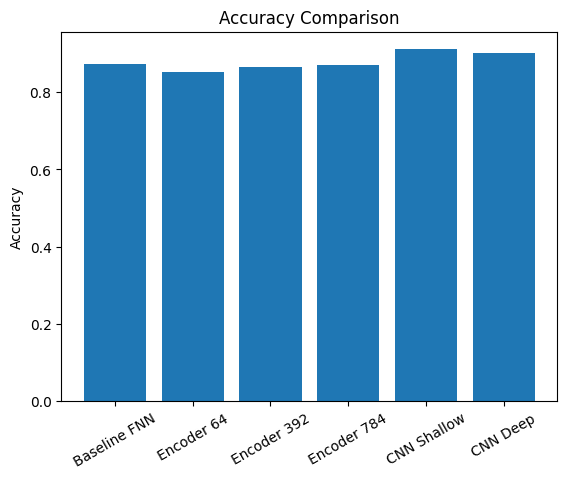

In [9]:
models = [r[0] for r in results]
acc = [r[1] for r in results]

# Find best model based on Accuracy
best_entry = max(results, key=lambda x: x[1])  # x[1] = accuracy

best_model_name = best_entry[0]
best_model = model_store[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_entry[1]:.4f}\n")

plt.figure()
plt.bar(models, acc)
plt.xticks(rotation=30)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

Validation Curves

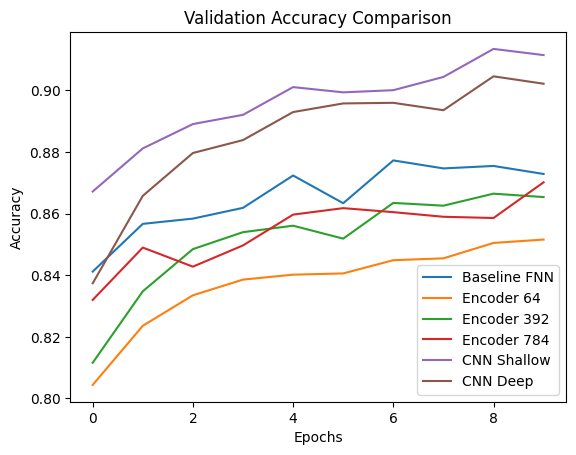

In [10]:
plt.figure()

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.legend()
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

Confusion Matrix


Best Model: CNN Shallow
Accuracy: 0.9115


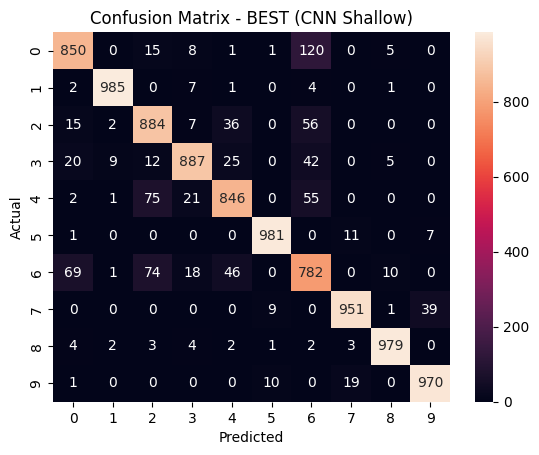

In [11]:
# Find BEST model (highest accuracy)
best_entry = max(results, key=lambda x: x[1])

best_model_name = best_entry[0]
best_model = model_store[best_model_name]

print(f"\nBest Model: {best_model_name}")
print(f"Accuracy: {best_entry[1]:.4f}")

# Select correct input data
if best_model_name in encoded_test_store:
    x_data = encoded_test_store[best_model_name]
elif "CNN" in best_model_name:
    x_data = x_test_cnn
else:
    x_data = x_test_flat

# Predictions
y_pred = best_model.predict(x_data, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - BEST ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Worst Model: Encoder 64
Accuracy: 0.8516


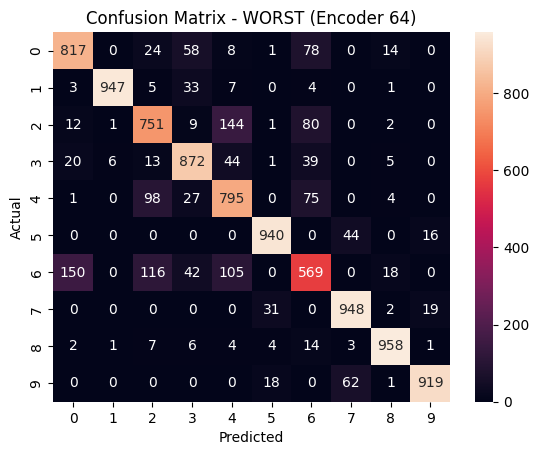

In [14]:
# Find WORST model (lowest accuracy)
worst_entry = min(results, key=lambda x: x[1])

worst_model_name = worst_entry[0]
worst_model = model_store[worst_model_name]

print(f"\nWorst Model: {worst_model_name}")
print(f"Accuracy: {worst_entry[1]:.4f}")

# Select correct input data
if worst_model_name in encoded_test_store:
    x_data = encoded_test_store[worst_model_name]
elif "CNN" in worst_model_name:
    x_data = x_test_cnn
else:
    x_data = x_test_flat

# Predictions
y_pred = worst_model.predict(x_data, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - WORST ({worst_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()